# Lab 3 - Homework

In [42]:
import os
import polars as pl
import matplotlib.pyplot as plt

### 1. Data reading

In [ ]:
# Load taxi zone lookup
taxi_zone_lookup = pl.scan_csv("data/taxi_zone_lookup.csv")

In [44]:
# Load all 2024 taxi data lazily
dfs = []
for month in range(1, 13):
    file_path = f"data/{month}.parquet"
    if os.path.exists(file_path):
        df = pl.scan_parquet(file_path)
        # Cast datetime columns to milliseconds to ensure consistent schema
        df = df.with_columns(
            pl.col("tpep_pickup_datetime").dt.cast_time_unit("ms"),
            pl.col("tpep_dropoff_datetime").dt.cast_time_unit("ms"),
        )
        dfs.append(df)

# Concatenate all months
df_all = pl.concat(dfs)

In [45]:
# Filter dates: pickup in 2024, dropoff <= 2025-01-01
df_all = df_all.filter(
    pl.col("tpep_pickup_datetime").dt.year() == 2024,
    pl.col("tpep_dropoff_datetime") <= pl.lit("2025-01-01").str.strptime(pl.Date, "%Y-%m-%d")
)

In [46]:
# Optimize data types
df_all = df_all.with_columns(
    pl.col("VendorID").cast(pl.Int8),
    pl.col("passenger_count").cast(pl.Int8),
    pl.col("RatecodeID").cast(pl.Int8),
    pl.col("PULocationID").cast(pl.Int16),
    pl.col("DOLocationID").cast(pl.Int16),
    pl.col("payment_type").cast(pl.Int8),
    pl.col("store_and_fwd_flag").cast(pl.Categorical),
    # Money columns as Float32
    pl.col("fare_amount").cast(pl.Float32),
    pl.col("extra").cast(pl.Float32),
    pl.col("mta_tax").cast(pl.Float32),
    pl.col("tip_amount").cast(pl.Float32),
    pl.col("tolls_amount").cast(pl.Float32),
    pl.col("improvement_surcharge").cast(pl.Float32),
    pl.col("total_amount").cast(pl.Float32),
    pl.col("congestion_surcharge").cast(pl.Float32),
    pl.col("Airport_fee").cast(pl.Float32),
    pl.col("trip_distance").cast(pl.Float32),
)

### 2. Data cleaning and filtering

In [47]:
# Cleaning
df_clean = df_all.with_columns(
    # Clean passenger_count: fill null with 1, cap at 6
    pl.when(pl.col("passenger_count").fill_null(1) > 6).then(6).otherwise(pl.col("passenger_count").fill_null(1)).alias("passenger_count"),
    # Absolute values for money columns
    pl.col("fare_amount").abs(),
    pl.col("extra").abs(),
    pl.col("mta_tax").abs(),
    pl.col("tip_amount").abs(),
    pl.col("tolls_amount").abs(),
    pl.col("improvement_surcharge").abs(),
    pl.col("total_amount").abs(),
    pl.col("congestion_surcharge").abs(),
    pl.col("Airport_fee").abs(),
)

In [48]:
# Filtering
df_clean = df_clean.filter(
    # Remove rides with zero passengers
    pl.col("passenger_count") > 0,
    # Trip duration <= 2 hours
    (pl.col("tpep_dropoff_datetime") - pl.col("tpep_pickup_datetime")).dt.total_minutes() <= 120,
    # No money column > 1000
    pl.col("fare_amount") <= 1000,
    pl.col("extra") <= 1000,
    pl.col("mta_tax") <= 1000,
    pl.col("tip_amount") <= 1000,
    pl.col("tolls_amount") <= 1000,
    pl.col("improvement_surcharge") <= 1000,
    pl.col("total_amount") <= 1000,
    pl.col("congestion_surcharge") <= 1000,
    pl.col("Airport_fee") <= 1000,
    # Valid VendorID and RatecodeID
    pl.col("VendorID").is_in([1, 2]),
    pl.col("RatecodeID").is_in([1, 2, 3, 4, 5, 6]),
)

### 3. Data transfomation

In [49]:
df_transformed = df_clean.with_columns(
    # Combine payment types
    pl.when(pl.col("payment_type").is_in([1])).then(pl.lit("credit"))
    .when(pl.col("payment_type").is_in([2])).then(pl.lit("cash"))
    .otherwise(pl.lit("other")).alias("payment_type"),
    # Add booleans
    (pl.col("Airport_fee") > 0).alias("is_airport_ride"),
    # Rush hour: weekdays, 6:30-9:30 or 15:30-20:00
    pl.when(
        pl.col("tpep_pickup_datetime").dt.weekday() <= 5,  # Mon-Fri
        (
            ((pl.col("tpep_pickup_datetime").dt.hour() + pl.col("tpep_pickup_datetime").dt.minute() / 60).is_between(6.5, 9.5)) |
            ((pl.col("tpep_pickup_datetime").dt.hour() + pl.col("tpep_pickup_datetime").dt.minute() / 60).is_between(15.5, 20.0))
        )
    ).then(True).otherwise(False).alias("is_rush_hour")
)

In [50]:
# Join with taxi zone lookup for PU and DO boroughs
df_transformed = df_transformed.join(
    taxi_zone_lookup.select(["LocationID", "Borough"]).rename({"Borough": "PU_Borough"}),
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
).join(
    taxi_zone_lookup.select(["LocationID", "Borough"]).rename({"Borough": "DO_Borough"}),
    left_on="DOLocationID",
    right_on="LocationID",
    how="left"
)

In [51]:
# Drop unnecessary columns
df_transformed = df_transformed.select([
    "tpep_pickup_datetime", "passenger_count", "trip_distance", "RatecodeID", "payment_type",
    "fare_amount", "extra", "mta_tax", "tip_amount", "tolls_amount", "improvement_surcharge",
    "total_amount", "congestion_surcharge", "Airport_fee", "PU_Borough", "DO_Borough",
    "is_airport_ride", "is_rush_hour"
])

### 4. Feature extraction

In [52]:
# Feature extraction: aggregate to daily
df_daily = df_transformed.group_by(
    pl.col("tpep_pickup_datetime").dt.date().alias("date")
).agg(
    # Target: total number of rides
    pl.len().alias("total_rides"),

    # Number of airport rides
    pl.col("is_airport_ride").sum().alias("airport_rides"),

    # Number of rush hour rides
    pl.col("is_rush_hour").sum().alias("rush_hour_rides"),

    # Aggregated features
    pl.col("fare_amount").mean().alias("avg_fare_amount"),
    pl.col("trip_distance").median().alias("median_distance"),
    pl.col("total_amount").sum().alias("sum_total_amount"),

    # Total amount by payment type (dummy encoding via sums)
    pl.when(pl.col("payment_type") == "credit").then(pl.col("total_amount")).otherwise(0).sum().alias("total_amount_credit"),
    pl.when(pl.col("payment_type") == "cash").then(pl.col("total_amount")).otherwise(0).sum().alias("total_amount_cash"),
    pl.when(pl.col("payment_type") == "other").then(pl.col("total_amount")).otherwise(0).sum().alias("total_amount_other"),

    # Total congestion surcharge
    pl.col("congestion_surcharge").sum().alias("total_congestion_surcharge"),

    # Total passengers
    pl.col("passenger_count").sum().alias("total_passengers"),

    # Borough counts (dummy encoding via counts)
    pl.when(pl.col("PU_Borough") == "Manhattan").then(1).otherwise(0).sum().alias("pu_manhattan"),
    pl.when(pl.col("PU_Borough") == "Brooklyn").then(1).otherwise(0).sum().alias("pu_brooklyn"),
    pl.when(pl.col("PU_Borough") == "Queens").then(1).otherwise(0).sum().alias("pu_queens"),
    pl.when(pl.col("PU_Borough") == "Bronx").then(1).otherwise(0).sum().alias("pu_bronx"),
    pl.when(pl.col("PU_Borough") == "Staten Island").then(1).otherwise(0).sum().alias("pu_staten_island"),
    pl.when(pl.col("PU_Borough") == "EWR").then(1).otherwise(0).sum().alias("pu_ewr"),
    pl.when(pl.col("PU_Borough") == "Unknown").then(1).otherwise(0).sum().alias("pu_unknown"),

    # Similarly for DO
    pl.when(pl.col("DO_Borough") == "Manhattan").then(1).otherwise(0).sum().alias("do_manhattan"),
    pl.when(pl.col("DO_Borough") == "Brooklyn").then(1).otherwise(0).sum().alias("do_brooklyn"),
    pl.when(pl.col("DO_Borough") == "Queens").then(1).otherwise(0).sum().alias("do_queens"),
    pl.when(pl.col("DO_Borough") == "Bronx").then(1).otherwise(0).sum().alias("do_bronx"),
    pl.when(pl.col("DO_Borough") == "Staten Island").then(1).otherwise(0).sum().alias("do_staten_island"),
    pl.when(pl.col("DO_Borough") == "EWR").then(1).otherwise(0).sum().alias("do_ewr"),
    pl.when(pl.col("DO_Borough") == "Unknown").then(1).otherwise(0).sum().alias("do_unknown"),
).sort("date")

# Add time features
df_daily = df_daily.with_columns(
    pl.col("date").dt.quarter().alias("quarter"),
    pl.col("date").dt.month().alias("month"),
    pl.col("date").dt.day().alias("day_of_month"),
    pl.col("date").dt.weekday().alias("day_of_week"),  # 1=Monday
    (pl.col("date").dt.weekday() >= 6).alias("is_weekend"),
)

# Save to parquet
df_daily.collect().write_parquet("dataset.parquet")

### 5. Data analysis

In [53]:
# Load the dataset
df_final = pl.read_parquet("dataset.parquet")

In [54]:
print("Shape:", df_final.shape)

print("\nTop rows:")
print(df_final.head())

print("\nDescribe statistics:")
print(df_final.describe())

print("\nSchema:")
print(df_final.schema)

Shape: (366, 31)

Top rows:
shape: (5, 31)
┌────────────┬────────────┬────────────┬───────────┬───┬───────┬───────────┬───────────┬───────────┐
│ date       ┆ total_ride ┆ airport_ri ┆ rush_hour ┆ … ┆ month ┆ day_of_mo ┆ day_of_we ┆ is_weeken │
│ ---        ┆ s          ┆ des        ┆ _rides    ┆   ┆ ---   ┆ nth       ┆ ek        ┆ d         │
│ date       ┆ ---        ┆ ---        ┆ ---       ┆   ┆ i8    ┆ ---       ┆ ---       ┆ ---       │
│            ┆ u32        ┆ u32        ┆ u32       ┆   ┆       ┆ i8        ┆ i8        ┆ bool      │
╞════════════╪════════════╪════════════╪═══════════╪═══╪═══════╪═══════════╪═══════════╪═══════════╡
│ 2024-01-01 ┆ 69541      ┆ 8352       ┆ 19415     ┆ … ┆ 1     ┆ 1         ┆ 1         ┆ false     │
│ 2024-01-02 ┆ 71444      ┆ 9828       ┆ 30654     ┆ … ┆ 1     ┆ 2         ┆ 2         ┆ false     │
│ 2024-01-03 ┆ 78399      ┆ 9140       ┆ 33060     ┆ … ┆ 1     ┆ 3         ┆ 3         ┆ false     │
│ 2024-01-04 ┆ 97896      ┆ 8270       ┆ 43267  

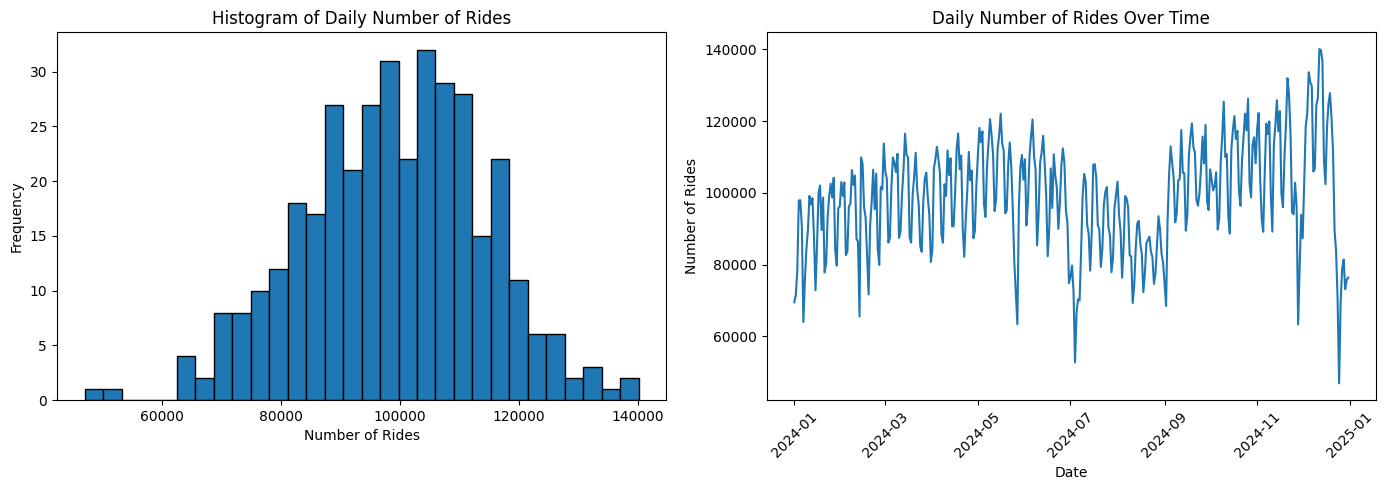

In [55]:
# Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of target
ax1.hist(df_final["total_rides"], bins=30, edgecolor='black')
ax1.set_title("Histogram of Daily Number of Rides")
ax1.set_xlabel("Number of Rides")
ax1.set_ylabel("Frequency")

# Line plot
ax2.plot(df_final["date"], df_final["total_rides"])
ax2.set_title("Daily Number of Rides Over Time")
ax2.set_xlabel("Date")
ax2.set_ylabel("Number of Rides")
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()